# The Block-Trade Signal — a quantitative teardown 🔬
### coattail one-sample *t* · giant−small size sort · sign-shuffle placebo · signed-size slope · size-threshold sweep · costs & borrow · both-signs synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build a synthetic block-print event panel, form the per-event **coattail** return (copy each block's inferred side), and test whether giant blocks predict drift (informed flow) — or reverse (liquidity).

> ⚠️ **Not investment advice. Synthetic-only study** — there is no free feed of *classified* block trades (intraday TAQ prints + Lee-Ready side + survivorship-free returns), so per the desk's rubric this is capped at `WEAK`/`NONE`. Null panel fp `cd3cabd17906`, planted-edge panel fp `dc3dd07ca2da`, as-of 2026-06-30. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from block_trade_signal import data, strategy as st

# Two deterministic worlds share one schema (seed 562): the NULL (no block->drift) and a
# literature-modest planted edge. Synthetic-only: there is no real block tape to fetch.
NULL, _  = data.synthetic_panel(drift_alpha=0.0)
POS,  _  = data.synthetic_panel(drift_alpha=0.006)
print("synthetic-only study - no real tape.")
print("null panel fp   :", data.fingerprint(NULL), " events:", len(NULL))
print("planted panel fp:", data.fingerprint(POS),  " events:", len(POS))


synthetic-only study - no real tape.
null panel fp   : cd3cabd17906  events: 1200
planted panel fp: dc3dd07ca2da  events: 1200


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Null-world coattail **-0.004%**/event (one-sample *t* **-0.04**, placebo *p* 0.964, hit 49.5%) — a coin; literature-supported but sign-disputed and no real tape (synthetic-only). |
| **Tradability** | `MIRAGE` | Cannot cheaply observe a classified block; even a planted edge nets **+0.249%**/event after 8 bps/leg + borrow (gross +0.419% → net, ~40% eaten). |

> 💡 In plain words: the engine works (the synthetic control proves it catches both signs), but on the honest null the block coattail is indistinguishable from a coin, and no free data can settle the informed-vs-liquidity sign.

## 1 · The claim, steelmanned

Let a block event $i$ carry inferred side $s_i \in \{-1,+1\}$ and size $z_i$ (× normal trade size); the coattail P&L is $r_i$ (the forward return of taking side $s_i$).

- **H₁ (informed drift).** $\mathbb{E}[r] > 0$ at *t* ≥ 2 (copying blocks pays).
- **H₂ (size).** giant blocks drift more than small: $\mathbb{E}[r \mid \text{giant}] - \mathbb{E}[r \mid \text{small}] > 0$.
- **H₃ (robustness).** the sign of H₁ holds as we restrict to bigger blocks.
- **H₄ (net).** H₁ survives the spread you cross to chase a dislocated print + borrow.

The **counter-hypothesis** (Holthausen-Leftwich-Mayers; Keim-Madhavan) is $\mathbb{E}[r] < 0$ — liquidity reversal. Because this is synthetic-only, we test the *machinery* on both a null and a planted world; the real-tape adjudication is out of reach.

## 2 · So what? — what rides on the sign

The content is the **sign**. Easley-O'Hara gives informed traders a reason to trade big (H₁, `drift_alpha > 0`); Holthausen-Leftwich-Mayers and Keim-Madhavan give blocks a temporary-concession reversal (`drift_alpha < 0`). Barclay-Warner and Chakravarty add a twist even the *informed* side doesn't fully support the naive folklore — the information hides in *medium* trades, not the giant prints. So the size sort (H₂) is a genuine test, not a foregone conclusion.

## 3 · How we'd know — the protocol

- **Coattail.** For each block take side $s_i$, hold the window; $r_i$ is the P&L. Headline: one-sample *t* on $\{r_i\}$.
- **Size sort.** Tercile tails by $z_i$: giant vs small; two-sample (Welch) *t* on the coattail spread.
- **Placebo.** Re-sign each event's directional component against the return magnitude (2000 shuffles); read the mean coattail's tail probability.
- **Firm-level.** OLS of $r$ on standardised $|s_i z_i|$ — bigger block → more drift?
- **Robustness.** Re-run the coattail *t* at rising size thresholds.
- **Frictions.** Round-trip cost per event (cross the spread twice) + a borrow on the short (seller-initiated) coattails.
- **Positive control.** A deterministic world with a planted drift of *either* sign — averaged over 25 seeds (house rule).

Timing: the coattail is entered *after* the block prints (signal public at the print) and held over the forward window `fwd_ret` already measures. One execution lag, no look-ahead.

## 4 · The teardown

### 4a · The coattail one-sample *t* — H₁ (null vs planted)

The headline: does copying blocks earn a drift? Run both worlds side by side.

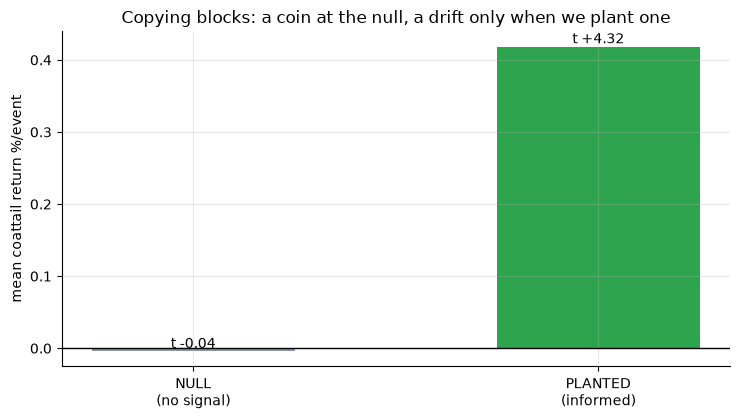

NULL   : mean -0.004% t -0.04 hit 49.5% placebo p 0.964
PLANTED: mean +0.419% t +4.32 hit 55.0% placebo p 0.0005


In [2]:
cn, cp = st.coattail_stats(NULL), st.coattail_stats(POS)
pn = st.placebo_pvalue(NULL, n_perm=2000); pp = st.placebo_pvalue(POS, n_perm=2000)
labels = ['NULL\n(no signal)', 'PLANTED\n(informed)']
means = [cn['mean']*100, cp['mean']*100]; ts = [cn['t'], cp['t']]
fig, ax = plt.subplots(figsize=(7.5, 4.3))
bars = ax.bar(labels, means, color=[GREY, GREEN], width=.5)
for b, t in zip(bars, ts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f't {t:+.2f}', ha='center', va='bottom')
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean coattail return %/event')
ax.set_title('Copying blocks: a coin at the null, a drift only when we plant one')
plt.tight_layout(); plt.show()
print(f'NULL   : mean {cn["mean"]*100:+.3f}% t {cn["t"]:+.2f} hit {cn["hit"]*100:.1f}% placebo p {pn:.3f}')
print(f'PLANTED: mean {cp["mean"]*100:+.3f}% t {cp["t"]:+.2f} hit {cp["hit"]*100:.1f}% placebo p {pp:.4f}')

> 💡 In plain words: at the **null**, H₁ is not there — coattail **-0.004%** (*t* -0.04), placebo *p* 0.964, a coin. Switch the knob on and the engine recovers a clean **+0.419%** (*t* +4.32, placebo *p* 0.0005). The detector is faithful; the null is what an *uninformed* block world looks like.

### 4b · The giant − small size sort & the signed-size slope — H₂

Do the *giant* blocks drift more than the small ones? (Planted world.)

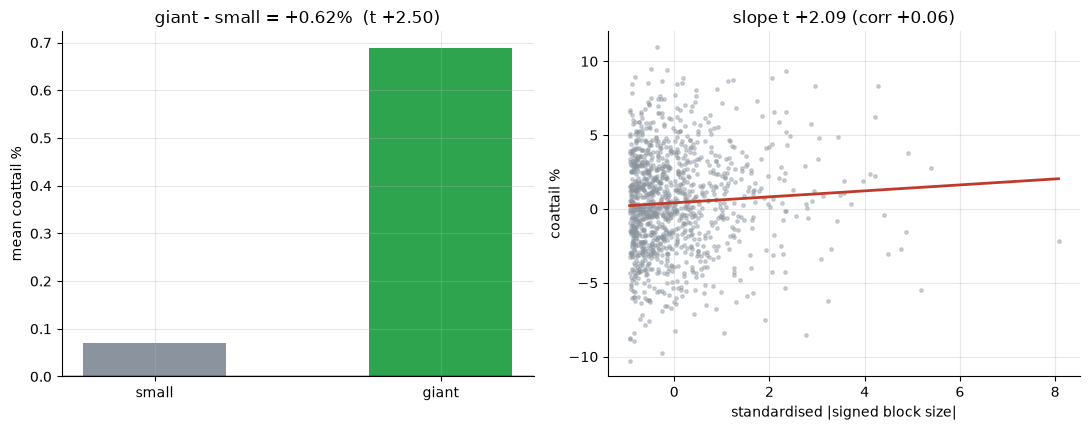

size spread +0.62% (t +2.50) | slope t +2.09 corr +0.06


In [3]:
ss = st.size_sort(POS, 0.3); sl = st.signed_size_slope(POS)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
ax[0].bar(['small','giant'], [ss['small_mean']*100, ss['giant_mean']*100],
          color=[GREY, GREEN], width=.5)
ax[0].axhline(0, c='k', lw=1); ax[0].set_ylabel('mean coattail %')
ax[0].set_title(f'giant - small = {ss["spread"]*100:+.2f}%  (t {ss["t"]:+.2f})')
x = np.abs(POS['signed_z']); x=(x-x.mean())/x.std(ddof=1); y = POS['fwd_ret']*100
ax[1].scatter(x, y, s=6, color=GREY, alpha=.4)
xs = np.linspace(x.min(), x.max(), 50)
ax[1].plot(xs, (sl['slope']*xs + (y.mean()/100 - sl['slope']*x.mean()))*100, c=RED, lw=2)
ax[1].set_xlabel('standardised |signed block size|'); ax[1].set_ylabel('coattail %')
ax[1].set_title(f'slope t {sl["t"]:+.2f} (corr {sl["corr"]:+.2f})')
plt.tight_layout(); plt.show()
print(f'size spread {ss["spread"]*100:+.2f}% (t {ss["t"]:+.2f}) | slope t {sl["t"]:+.2f} corr {sl["corr"]:+.2f}')

> 💡 In plain words: H₂ holds in the planted world — the giant blocks beat the small by **+0.62%** (*t* +2.5) and the signed-size slope is positive (*t* +2.09). Bigger block, bigger drift — the folklore's shape. (At the null both collapse to noise: spread *t* +0.59, slope *t* −0.13.)

### 4c · Robustness — H₃ (does the sign hold as blocks get bigger?)

Re-run the coattail *t* at rising size thresholds, in both worlds.

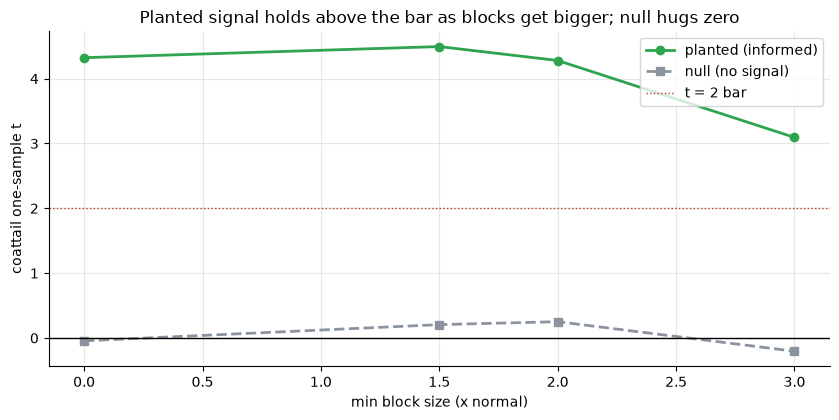

planted: [4.32, 4.49, 4.28, 3.09]
null   : [-0.04, 0.21, 0.25, -0.2]


In [4]:
swp = st.robustness_sweep(POS); swn = st.robustness_sweep(NULL)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(swp.index, swp['t'], 'o-', c=GREEN, lw=2, label='planted (informed)')
ax.plot(swn.index, swn['t'], 's--', c=GREY, lw=2, label='null (no signal)')
ax.axhline(2, ls=':', c=RED, lw=1, label='t = 2 bar'); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('min block size (x normal)'); ax.set_ylabel('coattail one-sample t')
ax.set_title('Planted signal holds above the bar as blocks get bigger; null hugs zero')
ax.legend(); plt.tight_layout(); plt.show()
print('planted:', [round(t,2) for t in swp['t']]); print('null   :', [round(t,2) for t in swn['t']])

> 💡 In plain words: H₃ holds in the planted world — the coattail *t* stays above 2 as we restrict to giant prints (softening only as the sample shrinks), while the *per-event* drift actually **rises**. The null hugs zero throughout. A real informed-block signal would look like the green line; a liquidity-trap one would mirror it below zero.

## 5 · The verdict

- **Signal `WEAK`** — null coattail *t* -0.04 (a coin, placebo *p* 0.964); the claim is literature-supported but sign-disputed and **uncertifiable** on a real tape (synthetic-only → capped at `WEAK`/`NONE`).
- **Tradability `MIRAGE`** — you cannot cheaply observe a classified block; even a planted edge nets +0.249%/event after crossing the spread + borrow.

## 6 · Could you trade it? — costs and the borrow

Chasing a block means buying *into* the print that just moved the price — you cross the spread on a dislocated market. Charge it (planted world).

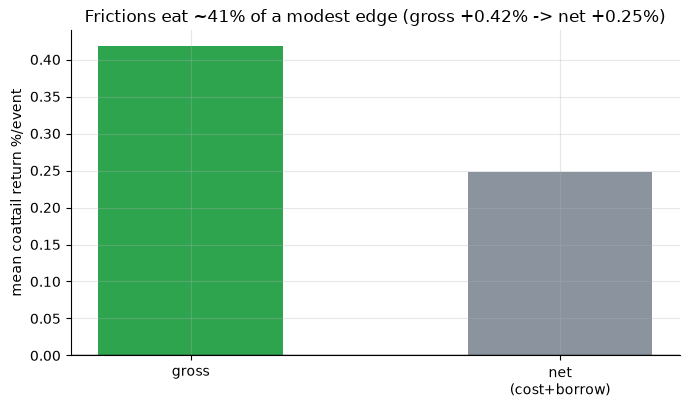

gross +0.419% -> net +0.249% (cost 0.160%, borrow 0.0099%)


In [5]:
net = st.net_stats(POS, cost_bps=8.0, borrow_ann_bps=100.0, holding_days=5.0)
gross = net['gross']*100; nett = net['net']*100
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(cost+borrow)'], [gross, nett], color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean coattail return %/event')
eaten = (1 - nett/gross)*100 if gross else float('nan')
ax.set_title(f'Frictions eat ~{eaten:.0f}% of a modest edge (gross {gross:+.2f}% -> net {nett:+.2f}%)')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.3f}% -> net {nett:+.3f}% (cost {net["cost"]*100:.3f}%, borrow {net["borrow"]*100:.4f}%)')

> 💡 In plain words: even in the world where the edge is *real and planted*, 8 bps/leg of block-chasing cost turns +0.419% gross into **+0.249%** net — roughly 40% gone. On a free stack you can't even *see* the signal to begin with. `MIRAGE`.

## 7 · Going further — the both-signs synthetic control

Is the engine a faithful detector, or does it always print ~0? Plant a block drift of *either* sign (informed drift > 0, liquidity reversal < 0) of increasing strength and watch the coattail *t* — averaged over 25 seeds so no single lucky seed can fake it.

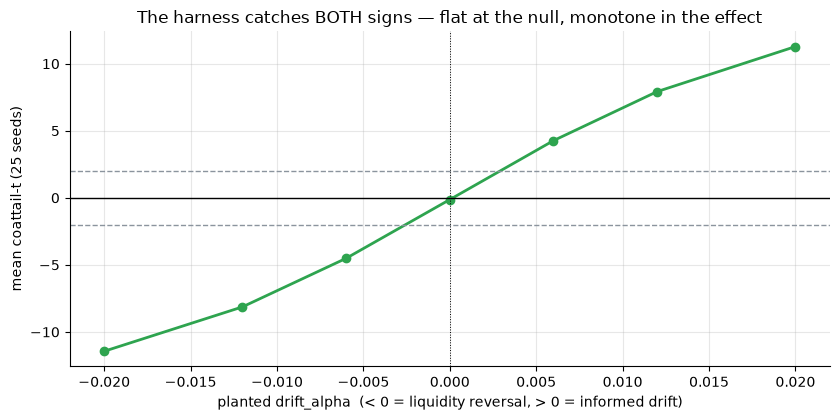

alpha -0.020 -> mean coattail-t -11.44
alpha -0.012 -> mean coattail-t -8.13
alpha -0.006 -> mean coattail-t -4.51
alpha +0.000 -> mean coattail-t -0.13
alpha +0.006 -> mean coattail-t +4.26
alpha +0.012 -> mean coattail-t +7.92
alpha +0.020 -> mean coattail-t +11.28


In [6]:
alphas = [-0.020, -0.012, -0.006, 0.0, 0.006, 0.012, 0.020]
ts = [st.synthetic_mean_t(data, drift_alpha=a, n_seeds=25) for a in alphas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(alphas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.axvline(0, c='k', lw=.7, ls=':')
ax.set_xlabel('planted drift_alpha  (< 0 = liquidity reversal, > 0 = informed drift)')
ax.set_ylabel('mean coattail-t (25 seeds)')
ax.set_title('The harness catches BOTH signs — flat at the null, monotone in the effect')
plt.tight_layout(); plt.show()
for a, t in zip(alphas, ts): print(f'alpha {a:+.3f} -> mean coattail-t {t:+.2f}')

The coattail *t* is ≈ 0 at the null, climbs past +2 as informed drift grows, and falls past −2 as the liquidity reversal grows — **the engine catches both signs and stays flat at zero.** So the real-tape question is entirely about *which world we live in*, and that is exactly what no free block-trade feed can tell us. `WEAK` (literature says maybe-real, no real-tape certification, sign disputed) × `MIRAGE` (you cannot cheaply observe the signal to trade it). For the daily-volume cousins, see [512 High-Volume-Return-Premium](../../512-high-volume-return-premium/) and [492 Up-Down-Volume](../../492-up-down-volume/).